In [129]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [130]:
from diffrax import diffeqsolve, ODETerm,VirtualBrownianTree,MultiTerm,ControlTerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

In [131]:
def model(x0, theta, key,days, delta_t):
    gamma,xi,damping,log_mean,log_std = theta
    log_beta_damping = damping
    log_beta_mean = log_mean
    log_beta_standard_deviation = log_std

    A = jnp.exp(-log_beta_damping * delta_t)
    M = log_beta_mean * (jnp.exp(-log_beta_damping * delta_t) - 1)
    C = log_beta_standard_deviation * jnp.sqrt(
        1 - jnp.exp(-2 * log_beta_damping * delta_t)
    )

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, R, log_beta = prev_x

        N = S + I + R

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 4)

        log_beta = A * log_beta - M + C * jax.random.normal(update_keys[0])

        dN_SI = jax.random.poisson(
            update_keys[1], jnp.exp(log_beta) * (S * I / N) * delta_t
        )
        dN_SI = jnp.minimum(dN_SI, S)

        dN_IR = jax.random.poisson(update_keys[2], I * gamma * delta_t)
        dN_IR = jnp.minimum(dN_IR, I)

        dN_RS = jax.random.poisson(update_keys[3], R * xi * delta_t)
        dN_RS = jnp.minimum(dN_RS, R)

        S = S - dN_SI + dN_RS
        I = I + dN_SI - dN_IR
        R = R + dN_IR - dN_RS

        return (jnp.array([S, I, R, log_beta]), next_key), jnp.array(
            [S, I, R, log_beta]
        )

    _,loop_val = jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=jnp.arange(0, days, delta_t),
    )

    return jnp.concatenate((x0[jnp.newaxis,:],loop_val))

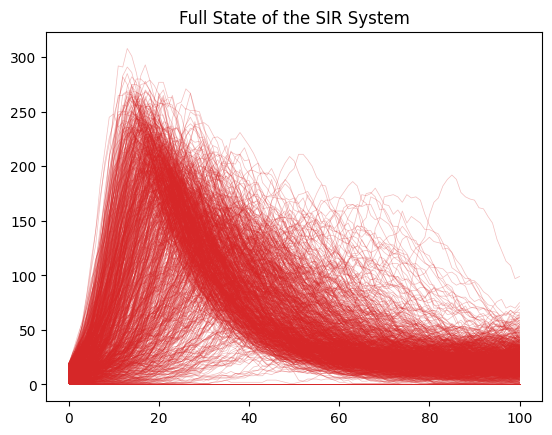

In [132]:
theta = (0.1, 1 / 90,1/35,jnp.log(0.35),0.2)
delta_t = 1.0
days = 100
rng_key = jax.random.key(0)

num_models = 1000
keys = jax.random.split(rng_key, num_models)

SIR_init_key, rng_key = jax.random.split(rng_key)
beta_init_key, rng_key = jax.random.split(rng_key)
I_x0 = jax.random.randint(SIR_init_key,minval = 0,maxval = 20,shape = (num_models,))

x0 = jnp.full(
    shape=(num_models, 3), fill_value=jnp.array([500, 0, 0])
)

x0 = x0.at[:,0].set(x0[:,0] - I_x0)
x0 = x0.at[:,1].set(x0[:,1] + I_x0)

beta_x0 = jax.random.uniform(beta_init_key,shape = (num_models,),minval = 0.1,maxval = 0.5)

beta_x0 = beta_x0[...,jnp.newaxis]

x0 = jnp.concatenate((x0,jnp.log(beta_x0)),axis = -1)

full_state = jax.vmap(model, in_axes=(0, None, 0, None, None))(
    x0, theta, keys, days, delta_t
)

plt.title("Full State of the SIR System")
for model_index in range(num_models):
    plt.plot(
        jnp.arange(0, days + delta_t, delta_t),
        full_state[model_index, :, 1],
        lw=0.5,
        alpha=0.3,
        color="tab:red",
    )
plt.show()

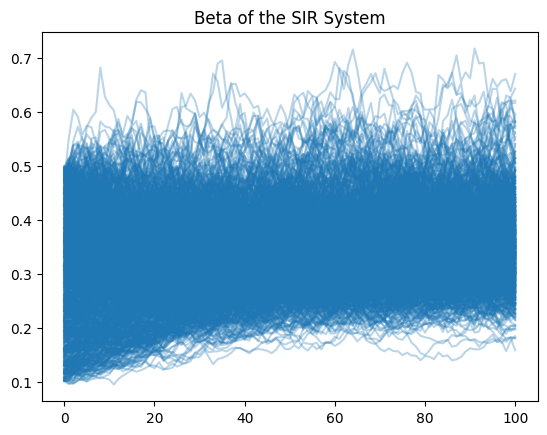

In [133]:
plt.title('Beta of the SIR System')
plt.plot(jnp.arange(0,days+delta_t,delta_t),jnp.exp(full_state[:,:,3]).T,color = 'tab:blue',alpha = 0.3)
plt.show()

In [134]:
### Forecasting

forecast_horizon = 4 * 7  # 4 weeks
cutoff_day = 15

num_ensemble_members = 25

theta_forecast = (0.1, 1 / 90,1/35,jnp.log(0.35),0.2)

def forecast_run(IC,theta,num_ensemble_members,key):
    ensemble_IC = jnp.full(
        fill_value=IC[int(cutoff_day / delta_t), :],
        shape=(num_ensemble_members, 4),
    )
    forecast_key, key = jax.random.split(key)
    forecast_keys = jax.random.split(forecast_key, num_ensemble_members)
    forecast = jax.vmap(model, in_axes=(0, None, 0, None, None))(
        ensemble_IC, theta, forecast_keys, forecast_horizon, delta_t
    )

    return forecast

forecast_key, rng_key = jax.random.split(rng_key)
forecast_keys = jax.random.split(forecast_key,num_models)
forecasts = jax.vmap(forecast_run,in_axes = (0,None,None,0))(full_state,theta_forecast,num_ensemble_members,forecast_keys)


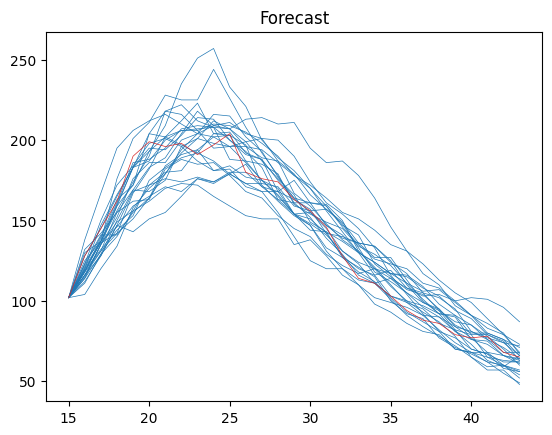

In [135]:
plt.plot(
    jnp.arange(cutoff_day, cutoff_day + forecast_horizon + delta_t, delta_t),
    forecasts[5, :,:, 1].T,
    lw=0.5,
    color="tab:blue",
)
plt.plot(
    jnp.arange(cutoff_day, cutoff_day + forecast_horizon + delta_t, delta_t),
    full_state[
        5,
        int(cutoff_day / delta_t) : int(cutoff_day / delta_t)
        + int(forecast_horizon / delta_t)
        + 1,
        1,
    ].T,
    lw=0.5,
    color="tab:red",
)

plt.title("Forecast")
plt.show()

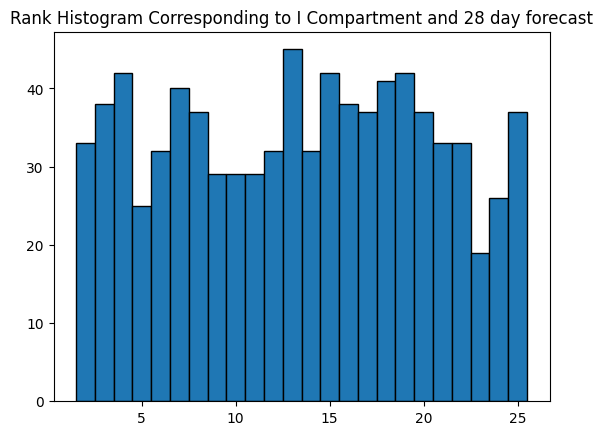

In [136]:
def get_rank_histogram(truth, ensemble):
    obs = truth[:,-1,jnp.newaxis]
    ens = ensemble

    def rank_eval(ens, obs):
        is_smaller = ens < obs
        num_smaller = jnp.sum(is_smaller,axis = 0)

        return num_smaller

    ranks = jax.vmap(rank_eval, in_axes=(0, 0))(ens, obs)

    return ranks


ranks = get_rank_histogram(
    full_state[
        :,
        int(cutoff_day / delta_t) : int(cutoff_day / delta_t)
        + int(forecast_horizon / delta_t)
        + 1,
        1,
    ],
    forecasts[:, :, -1, 1]
)

plt.title(
    f"Rank Histogram Corresponding to I Compartment and {forecast_horizon} day forecast"
)
plt.hist(
    ranks.reshape(-1),
    bins=jnp.arange(num_ensemble_members) + 2 - 0.5,
    edgecolor="black"
)
plt.show()

In [137]:
num_bins = num_ensemble_members + 1
rank_counts = jnp.bincount(ranks.reshape(-1), length=num_bins)

total_observations = ranks.shape[0]
expected_val = total_observations / num_bins
expected_counts = jnp.full(num_bins, expected_val)

def chi_square_test(observed, expected): 
    return jnp.sum(jnp.square(observed - expected) / expected)

stat = chi_square_test(rank_counts, expected_counts)
df = num_bins - 1

p_value = jax.scipy.stats.chi2.sf(stat, df)

print(f"Chi2 Stat: {stat:.2f}, df: {df}, p-value: {p_value:.4f}")

Chi2 Stat: 271.04, df: 25, p-value: 0.0000
